In [ ]:
#final project (cifar100)
#Author:"Vraj Diyora"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# dependencies
import keras
from keras.datasets import cifar100
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score





In [3]:


# define num_class
num_classes = 100

# load dataset keras will download cifar-100 datset
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')


x_train shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples


In [17]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


In [18]:
# Flatten the images
x_train_flat = x_train.reshape((len(x_train), -1))
x_test_flat = x_test.reshape((len(x_test), -1))

In [ ]:
# Define Logistic Regression model
lr_model = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(100, activation='softmax')
])

# Compile the model
lr_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# Train the model
lr_model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

# Evaluate the model
test_loss, test_accuracy = lr_model.evaluate(x_test, y_test)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)



Epoch 1/10
704/704 [==============================] - 7s 9ms/step - loss: 4.5698 - accuracy: 0.0172 - val_loss: 4.5375 - val_accuracy: 0.0268
Epoch 2/10
704/704 [==============================] - 7s 9ms/step - loss: 4.5058 - accuracy: 0.0434 - val_loss: 4.4797 - val_accuracy: 0.0610
Epoch 3/10
704/704 [==============================] - 6s 9ms/step - loss: 4.4492 - accuracy: 0.0673 - val_loss: 4.4283 - val_accuracy: 0.0766
Epoch 4/10
704/704 [==============================] - 5s 7ms/step - loss: 4.3986 - accuracy: 0.0770 - val_loss: 4.3828 - val_accuracy: 0.0820
Epoch 5/10
704/704 [==============================] - 10s 14ms/step - loss: 4.3533 - accuracy: 0.0881 - val_loss: 4.3426 - val_accuracy: 0.0856
Epoch 6/10
704/704 [==============================] - 9s 13ms/step - loss: 4.3125 - accuracy: 0.0909 - val_loss: 4.3068 - val_accuracy: 0.0944
Epoch 7/10
704/704 [==============================] - 6s 9ms/step - loss: 4.2763 - accuracy: 0.0980 - val_loss: 4.2733 - val_accuracy: 0.0940
Epo

Epoch 1/10
704/704 [==============================] - 6s 9ms/step - loss: 4.1609 - accuracy: 0.1107 - val_loss: 4.1707 - val_accuracy: 0.1050
Epoch 2/10
704/704 [==============================] - 5s 7ms/step - loss: 4.1378 - accuracy: 0.1149 - val_loss: 4.1510 - val_accuracy: 0.1052
Epoch 3/10
704/704 [==============================] - 5s 7ms/step - loss: 4.1167 - accuracy: 0.1176 - val_loss: 4.1329 - val_accuracy: 0.1072
Epoch 4/10
704/704 [==============================] - 6s 9ms/step - loss: 4.0974 - accuracy: 0.1196 - val_loss: 4.1138 - val_accuracy: 0.1110
Epoch 5/10
704/704 [==============================] - 5s 7ms/step - loss: 4.0794 - accuracy: 0.1227 - val_loss: 4.0971 - val_accuracy: 0.1118
Epoch 6/10
704/704 [==============================] - 5s 8ms/step - loss: 4.0625 - accuracy: 0.1242 - val_loss: 4.0822 - val_accuracy: 0.1198
Epoch 7/10
704/704 [==============================] - 6s 8ms/step - loss: 4.0466 - accuracy: 0.1258 - val_loss: 4.0696 - val_accuracy: 0.1198
Epoch 

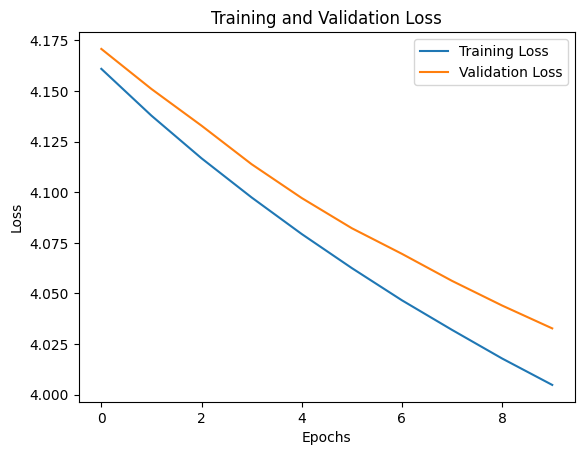

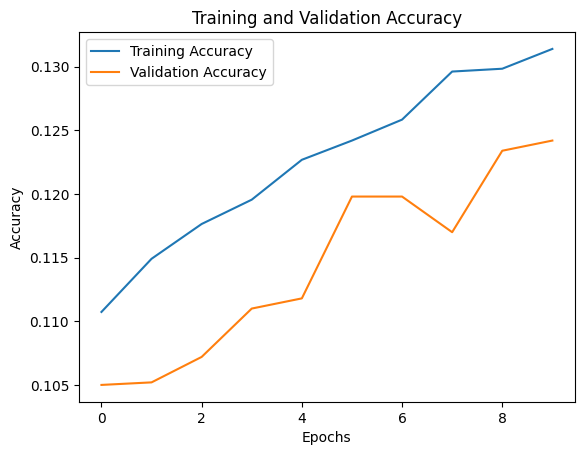

In [ ]:
import matplotlib.pyplot as plt

# Train the model
history = lr_model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [10]:
import keras
from keras.datasets import cifar100
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Load CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# Preprocess the data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to one-hot encoding
num_classes = 100
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# Define CNN model
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Train the model
cnn_model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

# Evaluate the model
test_loss, test_accuracy = cnn_model.evaluate(x_test, y_test)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)


Epoch 1/10
704/704 [==============================] - 106s 149ms/step - loss: 3.9057 - accuracy: 0.1068 - val_loss: 3.4600 - val_accuracy: 0.1800
Epoch 2/10
704/704 [==============================] - 99s 141ms/step - loss: 3.1582 - accuracy: 0.2292 - val_loss: 3.0217 - val_accuracy: 0.2596
Epoch 3/10
704/704 [==============================] - 104s 147ms/step - loss: 2.7741 - accuracy: 0.3040 - val_loss: 2.7895 - val_accuracy: 0.3000
Epoch 4/10
704/704 [==============================] - 112s 159ms/step - loss: 2.5081 - accuracy: 0.3560 - val_loss: 2.6471 - val_accuracy: 0.3320
Epoch 5/10
704/704 [==============================] - 105s 149ms/step - loss: 2.2954 - accuracy: 0.4020 - val_loss: 2.5756 - val_accuracy: 0.3516
Epoch 6/10
704/704 [==============================] - 105s 149ms/step - loss: 2.1348 - accuracy: 0.4366 - val_loss: 2.4910 - val_accuracy: 0.3732
Epoch 7/10
704/704 [==============================] - 104s 148ms/step - loss: 1.9912 - accuracy: 0.4677 - val_loss: 2.4126 - 

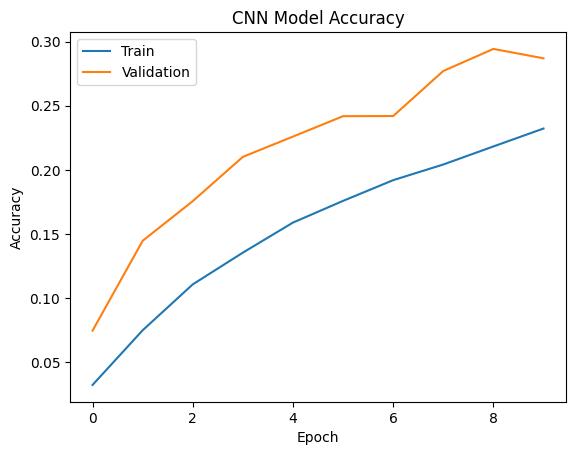

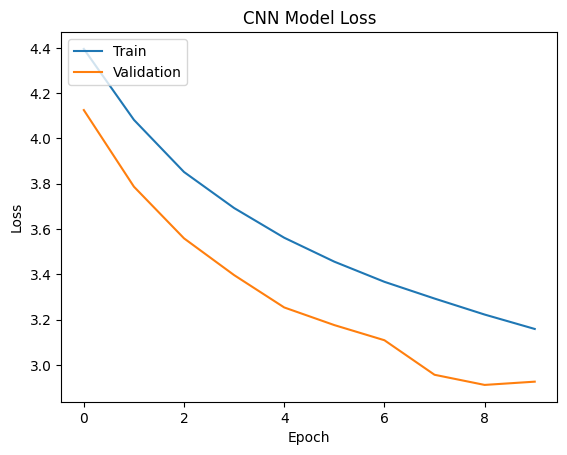

In [12]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


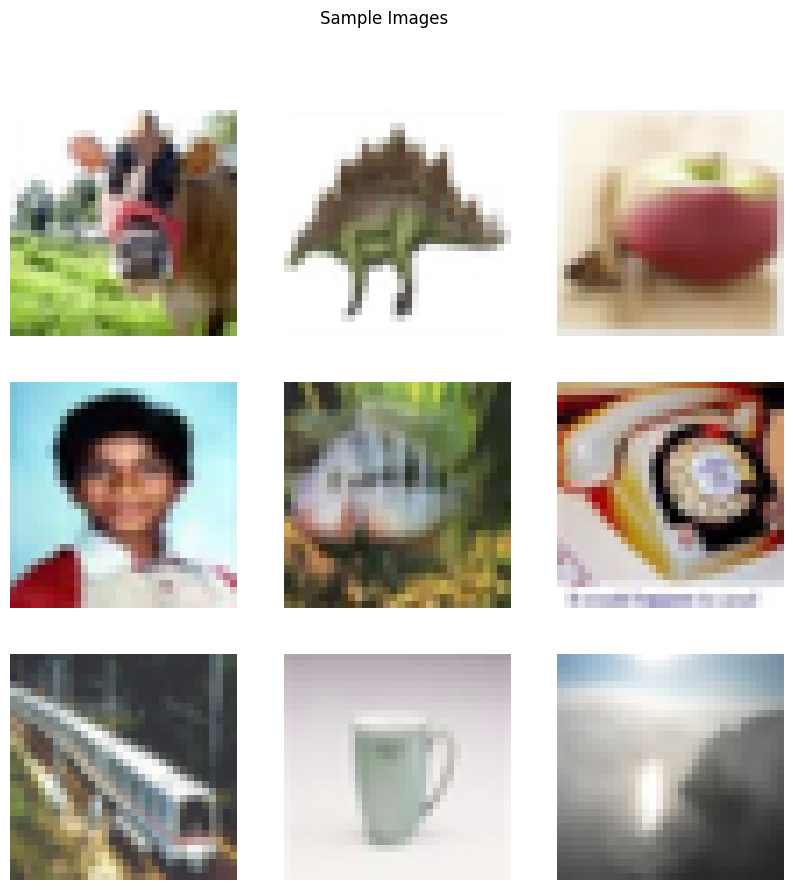

In [15]:
# Display sample images
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train[i])
    plt.axis('off')
plt.suptitle('Sample Images')
plt.show()
